# Targeting: does intervention economics justify contact?

Business question: under explicit effect, response, value, and cost assumptions, which targeting strategy has positive expected value?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
with (ARTIFACTS / "results.json").open() as handle:
    results = json.load(handle)

def table(name, n=8):
    frame = pd.read_csv(ARTIFACTS / "tables" / name)
    display(frame.head(n))
    return frame

def figure(name):
    png = ARTIFACTS / "figures" / f"{name}.png"
    svg = ARTIFACTS / "figures" / f"{name}.svg"
    assert png.exists() and svg.exists(), f"missing paired figure outputs for {name}"
    assert "<svg" in svg.read_text(encoding="utf-8")[:1000]
    display(Image(filename=str(png), width=640))
    return png, svg


,strategy,customers_contacted,contact_rate,expected_net_value,expected_net_value_per_contact,profitable
0,contact_all,11728,1.000000,-8566.734151,-0.730451,False
1,risk,1172,0.099932,-815.303196,-0.695651,False
2,value,1172,0.099932,-859.149832,-0.733063,False
3,response,1172,0.099932,-855.479988,-0.729932,False
4,expected_value,0,0.000000,0.000000,0.000000,False


,strategy,customers_contacted,contact_rate,expected_net_value,expected_net_value_per_contact,profitable,effect_multiplier,contact_cost_multiplier
0,expected_value,0,0.0,0.0,0.0,False,0.5,0.5
1,expected_value,0,0.0,0.0,0.0,False,0.5,1.0
2,expected_value,0,0.0,0.0,0.0,False,0.5,1.5
3,expected_value,0,0.0,0.0,0.0,False,1.0,0.5
4,expected_value,0,0.0,0.0,0.0,False,1.0,1.0
5,expected_value,0,0.0,0.0,0.0,False,1.0,1.5
6,expected_value,0,0.0,0.0,0.0,False,1.5,0.5
7,expected_value,0,0.0,0.0,0.0,False,1.5,1.0
8,expected_value,0,0.0,0.0,0.0,False,1.5,1.5


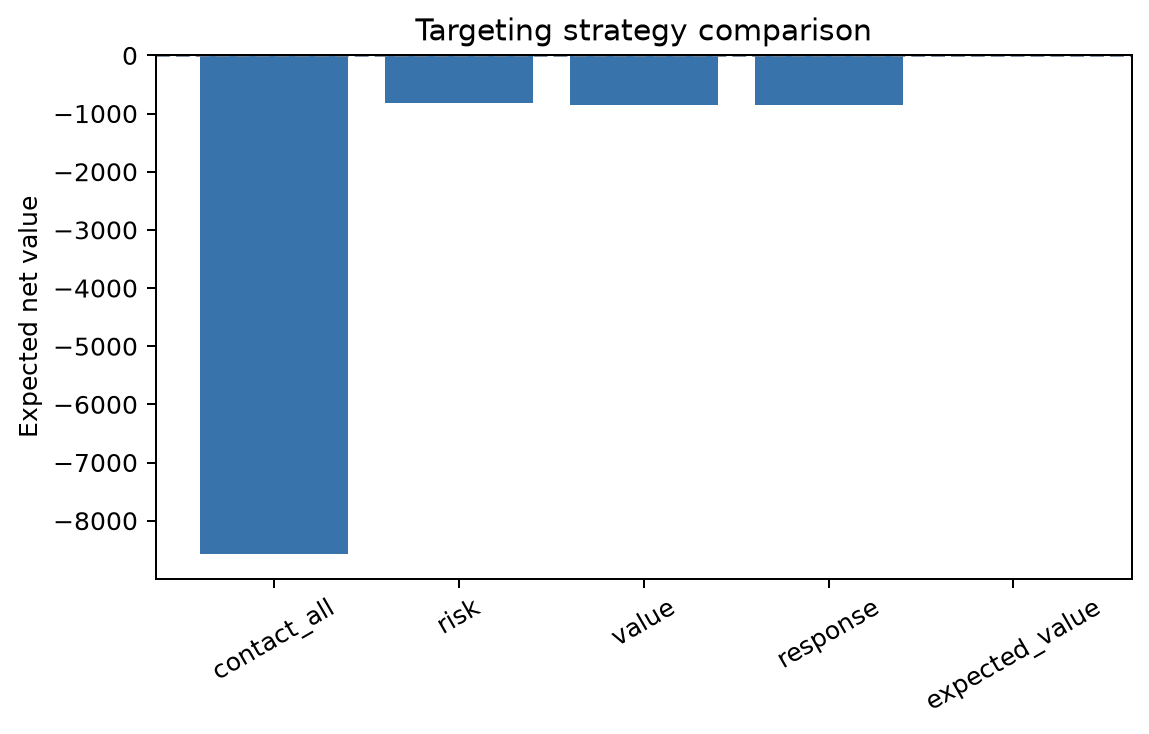

{'assumptions': {'treatment_effect_if_response': 0.12, 'contact_cost': 0.25, 'incentive_cost': 0.5, 'capacity_fraction': 0.1}, 'strategy_table': 'targeting_strategy_comparison.csv', 'sensitivity_table': 'economics_sensitivity.csv', 'decision_summary': {'best_strategy': 'expected_value', 'evaluated_population': 11728, 'customers_contacted': 0, 'contact_rate': 0.0, 'expected_net_value': 0.0, 'expected_net_value_per_10k': 0.0}, 'claim_scope': 'Scenario analysis conditional on stated fictional unit-economics assumptions.'}


In [2]:
strategies = table('targeting_strategy_comparison.csv', n=12)
sensitivity = table('economics_sensitivity.csv', n=12)
figure('targeting_strategy_value')
print(results['economics'])

In [3]:
best = strategies.sort_values('expected_net_value', ascending=False).iloc[0]
print(f"Evidence: the highest expected net value strategy is {best['strategy']!r}; profitability is recorded in the generated comparison.")
print('Decision: contact only where expected value remains positive across a decision-relevant sensitivity range, then validate with an experiment.')

Evidence: the highest expected net value strategy is 'expected_value'; profitability is recorded in the generated comparison.
Decision: contact only where expected value remains positive across a decision-relevant sensitivity range, then validate with an experiment.


**Uncertainty and scope.** Uncertainty: expected value is assumption-driven and response propensity is predictive. It is not evidence that contacted customers will realise the assumed incremental effect.

**Decision framing.** Treat the generated artifacts as an auditable working read: inspect the source table, check assumptions, and validate the proposed action with an appropriate follow-up measurement.